# Monte Carlo Validation

Compare theoretical vs empirical distributions from simulated trajectories.

In [2]:
import sympy as sp
from sympy import Matrix, sqrt, symbols
import mct
import numpy as np
import matplotlib.pyplot as plt

# Derive T1 symbolic matrix
lam = symbols('lambda', real=True, positive=True)
K0 = Matrix([[1, 0], [0, sqrt(1 - lam)]])
K1 = Matrix([[0, sqrt(lam)], [0, 0]])
P_sym, _ = mct.derive_transition_matrix([K0, K1], mct.computational_basis)

# Numeric matrix at λ=0.2 using mct API
P, _ = mct.substitute_and_verify(P_sym, lam, 0.2, name="")
print(f"Transition matrix P (λ=0.2):\n{P}")

Transition matrix P (λ=0.2):
[[1.  0.2]
 [0.  0.8]]


Theoretical distribution: [0.67232 0.32768]
Empirical distribution:   [0.6767 0.3233]
L2 error: 0.00619426


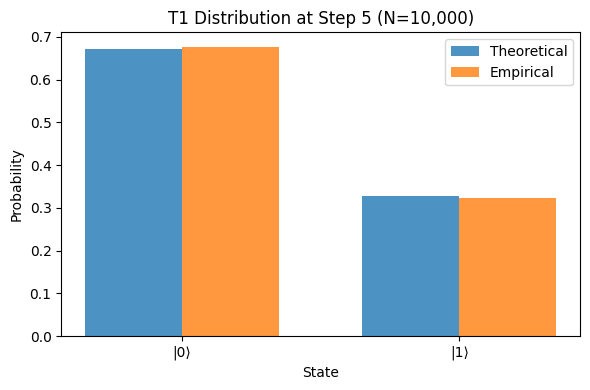

In [3]:
# Compare theory vs empirical
n_steps = 5
n_traj = 10000

# Theoretical distribution
theory_dist = mct.theoretical_distribution_after_steps(P, initial_state=1, n_steps=n_steps)

# Empirical from trajectories
trajectories = mct.simulate_markov_vectorized(P, initial_state=1, n_steps=n_steps, n_trajectories=n_traj)
empirical_dist = mct.empirical_distribution_from_trajectories(trajectories, step=n_steps, n_states=2)

# Error
error = np.linalg.norm(theory_dist - empirical_dist)
print(f"Theoretical distribution: {theory_dist}")
print(f"Empirical distribution:   {empirical_dist}")
print(f"L2 error: {error:.8f}")

# Plot
plt.figure(figsize=(6, 4))
x = np.arange(2)
width = 0.35
plt.bar(x - width/2, theory_dist, width, label='Theoretical', alpha=0.8)
plt.bar(x + width/2, empirical_dist, width, label='Empirical', alpha=0.8)
plt.xlabel('State')
plt.ylabel('Probability')
plt.title(f'T1 Distribution at Step {n_steps} (N={n_traj:,})')
plt.xticks(x, ['|0⟩', '|1⟩'])
plt.legend()
plt.tight_layout()
plt.show()

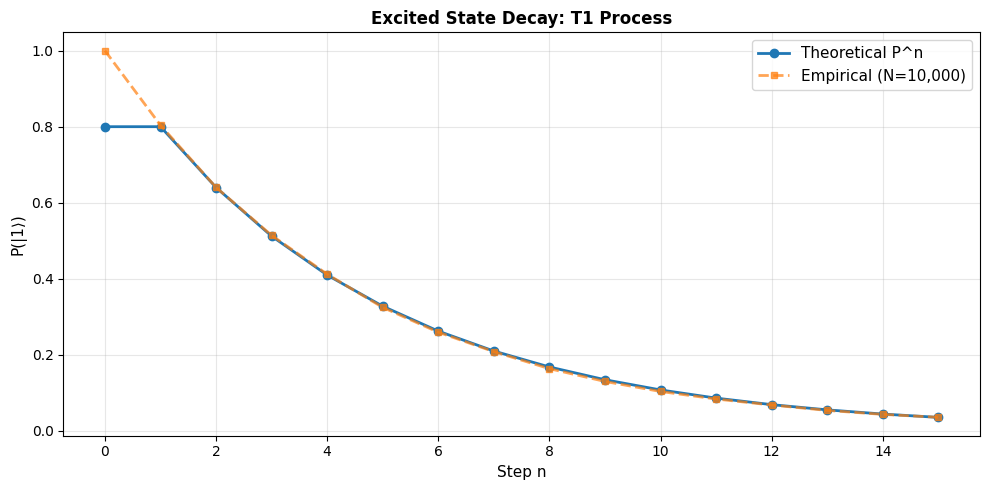


Max error over 15 steps: 0.20000000
Expected ~O(1/√N) = O(1/1.0e+02) = 0.01000000


In [4]:
# Excited state population decay over time
n_steps_max = 15
trajectories_long = mct.simulate_markov_vectorized(P, initial_state=1, n_steps=n_steps_max, n_trajectories=n_traj)

theory_decay = np.array([mct.theoretical_distribution_after_steps(P, initial_state=1, n_steps=n)[1] 
                         for n in range(n_steps_max + 1)])
empirical_decay = np.array([mct.empirical_distribution_from_trajectories(trajectories_long, step=n, n_states=2)[1] 
                           for n in range(n_steps_max + 1)])

plt.figure(figsize=(10, 5))
steps = np.arange(n_steps_max + 1)
plt.plot(steps, theory_decay, 'o-', label='Theoretical P^n', linewidth=2, markersize=6)
plt.plot(steps, empirical_decay, 's--', label=f'Empirical (N={n_traj:,})', linewidth=2, markersize=5, alpha=0.7)
plt.xlabel('Step n', fontsize=11)
plt.ylabel('P(|1⟩)', fontsize=11)
plt.title('Excited State Decay: T1 Process', fontsize=12, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

max_error = np.linalg.norm(theory_decay - empirical_decay, np.inf)
print(f"\nMax error over {n_steps_max} steps: {max_error:.8f}")
print(f"Expected ~O(1/√N) = O(1/{np.sqrt(n_traj):.1e}) = {1/np.sqrt(n_traj):.8f}")